In [1]:
import pandas as pd
import numpy as np

In [2]:
url = 'https://www.cbr.ru/vfs/hd_base/RReserves/required_reserves_table.xlsx'
df = pd.read_excel(url, header=2, skipfooter=8, usecols=[0,1,2])
df.columns = ['m1_data', 'm1_fact', 'm1_need']
print(df.head())

     m1_data     m1_fact  m1_need
0 2004-09-01  195.456667      8.7
1 2004-10-01  231.540323      9.1
2 2004-11-01  282.488333     11.5
3 2004-12-01  368.259677     12.0
4 2005-01-01  356.675806     12.7


In [3]:
df['m1_data'] = pd.to_datetime(df['m1_data'])

threshold_date = '2010-01-11'

df_filtered = df[df['m1_data'] >= threshold_date]
print(df_filtered.head())

      m1_data     m1_fact  m1_need
65 2010-02-10  476.219643    203.5
66 2010-03-10  510.719355    197.1
67 2010-04-10  500.551667    185.6
68 2010-05-10  504.333871    205.3
69 2010-06-10  572.043333    206.8


In [4]:
url2 = "https://www.cbr.ru/Queries/UniDbQuery/DownloadExcel/14315?Posted=True&From=11.01.2010&To=15.04.2026&FromDate=01%2F11%2F2010&ToDate=04%2F15%2F2026&backUrl=%2Fhd_base%2Fruonia%2Fdynamics%2F%3FUniDbQuery.Posted%3DTrue%26UniDbQuery.From%3D11.01.2010%26UniDbQuery.To%3D15.04.2026"
df2_ruon = pd.read_excel(url2, usecols=[0,1,2,5,8])
df2_ruon['ruo_data'] = pd.to_datetime(df2_ruon['DT'])
df2_ruon.head()


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,DT,ruo,vol,MinRate,MaxRate,ruo_data
0,2026-04-15,14.54,771.16,13.8,14.75,2026-04-15
1,2026-04-14,14.49,901.89,13.8,14.70,2026-04-14
2,2026-04-13,14.69,965.68,13.8,14.80,2026-04-13
3,2026-04-10,14.77,992.43,13.8,14.90,2026-04-10
4,2026-04-09,14.81,1047.44,13.8,14.95,2026-04-09


In [5]:
all_dates = pd.Series(pd.date_range(
    start=min(df2_ruon['ruo_data'].min(), df['m1_data'].min()),
    end=max(df2_ruon['ruo_data'].max(), df['m1_data'].max()),
    freq='D'
))

# 3. Создаем DataFrame со всеми датами
df_full = pd.DataFrame({'data': all_dates})

# 4. Добавляем месячные данные (из df) в полную таблицу
df_full = pd.merge(df_full, df, left_on='data', right_on='m1_data', how='left')

# 5. Интерполируем колонки m1_fact и m1_need
#    (линейная интерполяция = среднее между соседними месяцами)
df_full['m1_fact'] = df_full['m1_fact'].interpolate(method='linear')
df_full['m1_need'] = df_full['m1_need'].interpolate(method='linear')

# 6. Удаляем лишнюю колонку m1_data
df_full = df_full.drop('m1_data', axis=1)

# 7. Делаем join с df2 (ежедневными данными)
df_result = pd.merge(df2_ruon, df_full, left_on='ruo_data', right_on='data', how='left')

# 8. Проверяем результат
print("Первые 20 строк результата:")
df_result.head(2)

Первые 20 строк результата:


,DT,ruo,vol,MinRate,MaxRate,ruo_data,data,m1_fact,m1_need
0,2026-04-15,14.54,771.16,13.8,14.75,2026-04-15,2026-04-15,5407.2,5315.500000
1,2026-04-14,14.49,901.89,13.8,14.70,2026-04-14,2026-04-14,5407.2,5315.097143


In [6]:
df_final = df_result.copy()
df_final['m1_shift'] = df_final['m1_fact'] - df_final['m1_need']

df_final = df_final.rename(columns={
    'data': 'm1_data',
    'ruo': 'm1_ruo',
    'vol': 'm1_vol',
    'MinRate': 'm1_MinRate',
    'MaxRate': 'm1_MaxRate'
})

# Reordering columns
cols = ['m1_data', 'm1_fact', 'm1_need', 'm1_shift', 'm1_ruo', 'm1_vol', 'm1_MinRate', 'm1_MaxRate']
df_final = df_final[cols]

df_final.head(10)

,m1_data,m1_fact,m1_need,m1_shift,m1_ruo,m1_vol,m1_MinRate,m1_MaxRate
0,2026-04-15,5407.2,5315.500000,91.700000,14.54,771.16,13.80,14.75
1,2026-04-14,5407.2,5315.097143,92.102857,14.49,901.89,13.80,14.70
2,2026-04-13,5407.2,5314.694286,92.505714,14.69,965.68,13.80,14.80
3,2026-04-10,5407.2,5313.485714,93.714286,14.77,992.43,13.80,14.90
4,2026-04-09,5407.2,5313.082857,94.117143,14.81,1047.44,13.80,14.95
5,2026-04-08,5407.2,5312.680000,94.520000,14.83,689.35,13.80,14.90
6,2026-04-07,5407.2,5312.277143,94.922857,14.83,806.05,13.80,14.95
7,2026-04-06,5407.2,5311.874286,95.325714,14.88,785.47,14.48,15.00
8,2026-04-03,5407.2,5310.665714,96.534286,14.92,861.40,14.70,15.25
9,2026-04-02,5407.2,5310.262857,96.937143,14.91,630.47,14.65,15.25


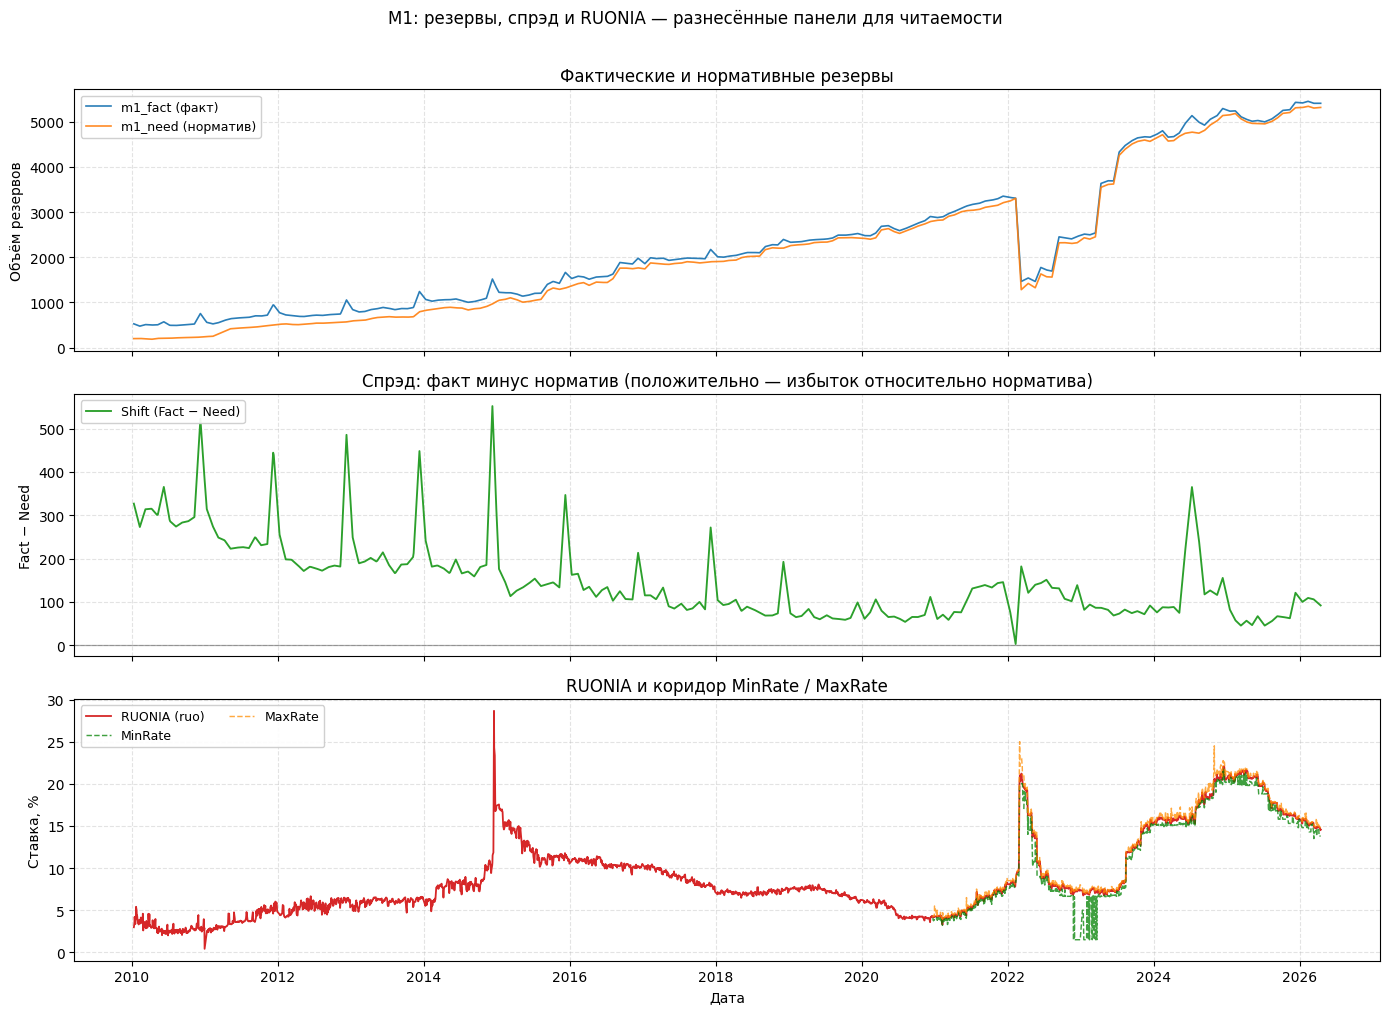

In [7]:
import matplotlib.pyplot as plt

# Один общий временной порядок
_d = df_final.sort_values("m1_data")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# --- Панель 1: уровни резервов (одна шкала, линии не конкурируют со спрэдом) ---
ax0 = axes[0]
ax0.plot(_d["m1_data"], _d["m1_fact"], label="m1_fact (факт)", color="tab:blue", lw=1.2, alpha=0.95)
ax0.plot(_d["m1_data"], _d["m1_need"], label="m1_need (норматив)", color="tab:orange", lw=1.2, alpha=0.9)
ax0.set_ylabel("Объём резервов")
ax0.set_title("Фактические и нормативные резервы")
ax0.legend(loc="upper left", fontsize=9, framealpha=0.92)
ax0.grid(True, linestyle="--", alpha=0.35)

# --- Панель 2: отклонение факта от норматива (отдельная ось) ---
ax1 = axes[1]
ax1.plot(_d["m1_data"], _d["m1_shift"], label="Shift (Fact − Need)", color="tab:green", lw=1.35)
ax1.axhline(0, color="black", lw=0.9, linestyle="-", alpha=0.35)
ax1.set_ylabel("Fact − Need")
ax1.set_title("Спрэд: факт минус норматив (положительно — избыток относительно норматива)")
ax1.legend(loc="upper left", fontsize=9, framealpha=0.92)
ax1.grid(True, linestyle="--", alpha=0.35)

# --- Панель 3: RUONIA и коридор ставок (%), без смешения с объёмами ---
ax2 = axes[2]
ax2.plot(_d["m1_data"], _d["m1_ruo"], label="RUONIA (ruo)", color="tab:red", lw=1.3)
ax2.plot(_d["m1_data"], _d["m1_MinRate"], label="MinRate", color="green", ls="--", lw=1.05, alpha=0.75)
ax2.plot(_d["m1_data"], _d["m1_MaxRate"], label="MaxRate", color="darkorange", ls="--", lw=1.05, alpha=0.75)
ax2.set_ylabel("Ставка, %")
ax2.set_xlabel("Дата")
ax2.set_title("RUONIA и коридор MinRate / MaxRate")
ax2.legend(loc="upper left", fontsize=9, framealpha=0.92, ncol=2)
ax2.grid(True, linestyle="--", alpha=0.35)

fig.suptitle("M1: резервы, спрэд и RUONIA — разнесённые панели для читаемости", y=1.01, fontsize=12)
fig.tight_layout()
plt.show()


1. Фактические и обязательные резервы (m1_fact и m1_need):

Как фактические резервы (m1_fact), так и обязательные резервы (m1_need) демонстрируют чёткий долгосрочный восходящий тренд. Это указывает на рост банковской системы и экономики в целом за наблюдаемый период.

Разрыв между m1_fact и m1_need не является постоянным, что говорит о колебаниях общей ситуации с ликвидностью.

2. Резервный спред (m1_shift):

Показатель m1_shift (фактические резервы минус обязательные резервы) представляет собой избыток или дефицит ликвидности в банковской системе. Положительное значение означает избыток резервов, а отрицательное — дефицит.

График показывает, что банковская система на протяжении большей части периода работала со значительным избытком ликвидности, поскольку m1_shift в основном является положительным.

Наблюдаются заметные колебания и периоды, когда избыток может сокращаться или расширяться, что указывает на меняющиеся условия ликвидности.

3. RUONIA и процентный коридор (m1_ruo, m1_MinRate, m1_MaxRate):

Ставка RUONIA (m1_ruo) в целом стремится оставаться в рамках установленного центральным банком процентного коридора, ограниченного значениями m1_MinRate и m1_MaxRate.

Когда в банковской системе наблюдается большой избыток ликвидности (высокий m1_shift), RUONIA, как правило, тяготеет к нижней границе (m1_MinRate), поскольку банки с избыточными средствами готовы кредитовать по более низким ставкам.

И наоборот, в периоды дефицита или ужесточения ликвидности RUONIA может смещаться ближе к верхней границе (m1_MaxRate).

График позволяет визуально идентифицировать периоды, когда RUONIA приближается к границам коридора, что даёт представление об эффективности управления ликвидностью и денежно-кредитной политики центрального банка.

Общие выводы:

Сильный рост как фактических, так и обязательных резервов указывает на расширяющийся финансовый сектор.

Панель с графиком m1_shift даёт прямую оценку ежедневной ликвидности, что крайне важно для понимания ситуации на межбанковском рынке.

Связь между ликвидностью (m1_shift) и процентными ставками (m1_ruo) очевидна: более высокая ликвидность, как правило, соответствует более низким межбанковским ставкам внутри коридора, и наоборот.

Визуальное разделение этих трёх связанных, но различных по смыслу показателей на отдельных панелях улучшает восприятие информации и позволяет более чётко понять как их индивидуальную динамику, так и взаимосвязи.

In [8]:
df_final = df_final.sort_values('m1_data')

window_days = 3 * 365
epsilon = 1e-9

# Helper function for rolling MAD
def get_rolling_mad(series, window):
    return series.rolling(window=window, min_periods=1).apply(
        lambda x: np.median(np.abs(x - np.median(x)))
    )

# 1. Normalize 'shift'
shift_rolling_median = df_final['m1_shift'].rolling(window=window_days, min_periods=1).median()
shift_rolling_mad = get_rolling_mad(df_final['m1_shift'], window_days)
df_final['m1_shift_mad'] = (df_final['m1_shift'] - shift_rolling_median) / (shift_rolling_mad + epsilon)

# 2. Normalize 'ruo'
ruo_rolling_median = df_final['m1_ruo'].rolling(window=window_days, min_periods=1).median()
ruo_rolling_mad = get_rolling_mad(df_final['m1_ruo'], window_days)
df_final['m1_ruo_mad'] = (df_final['m1_ruo'] - ruo_rolling_median) / (ruo_rolling_mad + epsilon)

In [9]:
# 1. Расчет дней до конца периода (периоды с 15-го по 14-е число)
def get_days_to_end(dates):
    days = []
    for d in dates:
        # Если день >= 15, то конец периода - 14 число СЛЕДУЮЩЕГО месяца
        if d.day >= 15:
            if d.month == 12:
                end_date = d.replace(year=d.year + 1, month=1, day=14)
            else:
                end_date = d.replace(month=d.month + 1, day=14)
        # Если день < 15, то конец периода - 14 число ТЕКУЩЕГО месяца
        else:
            end_date = d.replace(month=d.month, day=14)

        days.append((end_date - d).days)
    return days

df_final['days_to_end'] = get_days_to_end(df_final['m1_data'])

# 2. Создаем флаг (1 если до конца периода 5 дней или меньше, иначе 0)
# ТЗ требует последние 3-5 дней, возьмем <= 5 для надежности
df_final['m1_Flag_EndOfPeriod'] = (df_final['days_to_end'] <= 5).astype(int)

# Удаляем вспомогательную колонку
df_final.drop(columns=['days_to_end'], inplace=True)

In [10]:
df_final.head(20)

,m1_data,m1_fact,m1_need,m1_shift,m1_ruo,m1_vol,m1_MinRate,m1_MaxRate,m1_shift_mad,m1_ruo_mad,m1_Flag_EndOfPeriod
4002,2010-01-11,527.039864,200.403226,326.636638,2.98,64.56,NaN,NaN,0.000000,0.000000,1
4001,2010-01-12,525.345856,200.506452,324.839405,3.10,62.19,NaN,NaN,-1.000000,1.000000,1
4000,2010-01-13,523.651849,200.609677,323.042171,3.40,83.47,NaN,NaN,-1.000000,2.500000,1
3999,2010-01-14,521.957842,200.712903,321.244938,3.59,79.41,NaN,NaN,-1.500000,1.619048,1
3998,2010-01-15,520.263834,200.816129,319.447705,4.21,63.90,NaN,NaN,-2.000000,2.700000,0
3997,2010-01-18,515.181812,201.125806,314.056006,3.36,78.26,NaN,NaN,-3.000000,-0.081633,0
3996,2010-01-19,513.487805,201.229032,312.258772,3.39,77.10,NaN,NaN,-2.500000,0.000000,0
3995,2010-01-20,511.793797,201.332258,310.461539,4.10,76.74,NaN,NaN,-1.833333,2.877551,0
3994,2010-01-21,510.099790,201.435484,308.664306,4.02,72.74,NaN,NaN,-2.000000,2.066667,0
3993,2010-01-22,508.405783,201.538710,306.867073,5.41,88.36,NaN,NaN,-1.571429,4.208791,0
